# Simple portfolio optimization: training, validation, testing

A CRRA investor with risk aversion $\gamma$ chooses the fraction $f$ of wealth to place in a single risky asset. End-of-period wealth evolves under a piecewise wealth equation that distinguishes lending and borrowing:

$$
W_{t+1} = W_t \cdot \begin{cases}
1 + (1-f)\,r^f_t + f\,r^{\text{Mkt}}_t & f \le 1 \\
1 + f\,r^{\text{Mkt}}_t - (f-1)(r^f_t + s) & f > 1
\end{cases}
$$

When $f \le 1$ she lends $(1-f)$ at the risk-free rate $r^f_t$; when $f > 1$ she borrows $(f-1)$ at $r^f_t + s$. The borrowing spread $s > 0$ reflects margin rates, repo haircuts, and prime-broker spreads — i.e., the fact that real investors cannot borrow at $r^f$. We use **$s = 5\%$ annual** ($\approx 0.42\%$ per month) throughout, closer to what a retail investor faces (Schwab/Fidelity standard margin sits in the 7–13% range; institutional prime-brokerage spreads are 0.5–2%).

This notebook parallels the training/validation/testing analysis of Section 11.8 in Myerson & Zambrano, using monthly Fama–French market data and three candidate return models (Normal, Student-$t$, Johnson $S_U$). Unlike CRPS or other distributional-fit scoring rules, our selection criterion scores models by the realized performance of the decision they imply, on data the model has not seen.

- **Training (fitting): fold 1, 1926-07 to 1982-12, $n = 678$.** Fit each candidate by MLE. Simulate $10^5$ draws from each fit (truncated below at $m = -0.6$).
- **Optimization: compute $f^\star(\gamma, \text{model})$** for each $\gamma \in \{0.25, 0.5, 0.75, 1, 2, 3\}$ under the piecewise wealth equation above. To use the fitted $m$-distribution in the optimizer we recover $r^{\text{Mkt}} = \bar{r}^f + m(1 + \bar{r}^f)$ with $\bar{r}^f$ fixed at its fold-1 mean.
- **Validation: fold 2, 1983-01 to 2012-12, $n = 360$.** For each $(\gamma, \text{model})$ pair, evaluate realized mean utility on fold-2 returns under the same piecewise rule, using the actual $r^{\text{Mkt}}_t$ and $r^f_t$ for each month. The winning model per $\gamma$ is the one whose $f^\star$ delivers the highest realized mean utility on data it has not seen.
- **Testing: post-2012, $n = 159$.** For $\gamma \in \{0.5, 0.75, 1, 2, 3\}$, simulate the wealth path under each $\gamma$'s validation winner on realized test-set returns, again under the piecewise rule. Starting wealth $W_0 = 100{,}000$. With monthly data we have only about 13 calendar years of post-2012 returns; splitting them into two test folds would leave us underpowered to evaluate the strategy through a meaningful drawdown event, so we combine them into a single test fold.

Under free borrowing ($s = 0$, the textbook baseline) the same analysis would recommend substantially higher $f^\star$ when the unconstrained optimum exceeds 1, and would be unchanged at high $\gamma$ where $f^\star \le 1$ anyway.

In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from zipfile import ZipFile
from scipy import stats
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(607)

## Data and fold structure

Monthly Fama–French market data with the training/validation/test fold split described above. We keep both $m_t$ and the underlying $(r^{\text{Mkt}}_t, r^f_t)$ for each fold.

In [2]:
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
response = requests.get(url)
with ZipFile(BytesIO(response.content)) as zfile:
    csv_name = next(n for n in zfile.namelist() if n.lower().endswith(".csv"))
    with zfile.open(csv_name) as f:
        ff = pd.read_csv(f, skiprows=3, index_col=0)
ff = ff.apply(pd.to_numeric, errors="coerce").dropna()
ff = ff[ff.index.map(lambda s: s.isdigit() and len(s) == 6)]
ff["r_mkt"] = ff["Mkt-RF"] / 100 + ff["RF"] / 100
ff["r_f"]   = ff["RF"] / 100
ff["m"]     = (ff["r_mkt"] - ff["r_f"]) / (1 + ff["r_f"])

folds = {
    "training (fold 1)":   ff.loc["192607":"198212"],
    "validation (fold 2)": ff.loc["198301":"201212"],
    "test (folds 3+4)":    ff.loc["201301":],
}
pd.Series({k: len(v) for k, v in folds.items()}, name="n_obs")

training (fold 1)      678
validation (fold 2)    360
test (folds 3+4)       159
Name: n_obs, dtype: int64

## Training stage: fit three families on fold 1

In [3]:
train_m = folds["training (fold 1)"]["m"].values
families = {"Normal": stats.norm, "Student t": stats.t, "Johnson SU": stats.johnsonsu}
fits = {name: dist(*dist.fit(train_m)) for name, dist in families.items()}

pd.DataFrame({name: {"params": np.round(f.args + tuple(f.kwds.values()), 4)}
              for name, f in fits.items()}).T

,params
Normal,"[0.0064, 0.0587]"
Student t,"[3.4535, 0.0086, 0.0383]"
Johnson SU,"[0.2593, 1.2581, 0.0197, 0.0498]"


## Simulate $10^5$ draws from each fit, truncated at $m = -0.6$

Heavy sampling so rare events that the model puts probability on get a chance to show up. We then clip simulated draws below $m = -0.6$ — about twice the worst monthly market return ever observed in U.S. history ($\approx -0.30$, Sep 1931 / Oct 1987). The clip applies *only to the simulated draws used by the optimizer*; realized validation- and test-fold returns are used as-is. This stops the optimizer from being driven by tail regions that are physically impossible (e.g., Student-$t$ draws below $-1$, which would imply a single-month market loss of more than 100%).

In [4]:
n_simulations = 100_000
M_FLOOR = -0.6

child_seeds = rng.bit_generator._seed_seq.spawn(len(fits))
raw_draws = {name: f.rvs(size=n_simulations, random_state=np.random.default_rng(seed))
             for (name, f), seed in zip(fits.items(), child_seeds)}
draws = {name: np.maximum(x, M_FLOOR) for name, x in raw_draws.items()}

pd.DataFrame({
    name: {"m_min (raw)": raw_draws[name].min(),
           "m_max (raw)": raw_draws[name].max(),
           "# clipped at m=-0.6": int((raw_draws[name] < M_FLOOR).sum())}
    for name in fits
}).T.round(3)

,m_min (raw),m_max (raw),# clipped at m=-0.6
Normal,-0.242,0.260,0.0
Student t,-1.819,0.965,17.0
Johnson SU,-0.614,0.502,1.0


## Optimizer: CRRA expected utility under the piecewise wealth equation

We maximize $\mathbb{E}[u_\gamma(W_{t+1}/W_t)]$ over $f \in [0, f_{\max}]$ with $f_{\max} = 5$ — an economic leverage cap (5× equity is well beyond what any realistic borrowing arrangement supports). When $f \le 1$ the per-period gross return is $1 + (1-f)\,r^f + f\,r^{\text{Mkt}}$; when $f > 1$ the borrowed dollars cost $r^f + s$, where $s$ is the borrowing spread. For draws where $W_{t+1}/W_t \le 0$, the CRRA utility is genuinely $-\infty$ (ruin), but a literal `-inf` breaks the optimizer's bracket search. We instead use a smooth floor: replace any non-positive gross return with a tiny positive value $\epsilon = 10^{-12}$ before applying $u_\gamma$, so ruin is finite-but-huge-negative and the mean utility is continuous in $f$.

In [5]:
F_MAX = 5.0
EPS = 1e-12
S_ANNUAL = 0.05
S_MONTHLY = S_ANNUAL / 12.0
r_f_bar = folds["training (fold 1)"]["r_f"].mean()

def gross_return(f, r_mkt, r_f, spread):
    r_borrow = r_f + spread
    return np.where(f <= 1.0,
                    1.0 + (1.0 - f) * r_f + f * r_mkt,
                    1.0 + f * r_mkt - (f - 1.0) * r_borrow)

def neg_expected_utility(f, m_draws, gamma, spread=S_MONTHLY, r_f_const=None):
    if r_f_const is None:
        r_f_const = r_f_bar
    r_mkt = r_f_const + m_draws * (1.0 + r_f_const)
    w = np.maximum(gross_return(f, r_mkt, r_f_const, spread), EPS)
    u = np.log(w) if gamma == 1 else (w ** (1 - gamma) - 1) / (1 - gamma)
    return -u.mean()

def optimal_fraction(m_draws, gamma, spread=S_MONTHLY, f_max=F_MAX):
    res = minimize_scalar(neg_expected_utility, args=(m_draws, gamma, spread),
                          bounds=(0.0, f_max), method="bounded",
                          options={"xatol": 1e-6})
    return res.x

In [6]:
def wealth_path(fold_df, f, spread=S_MONTHLY, W0=100_000.0):
    r_mkt = fold_df["r_mkt"].values
    r_f   = fold_df["r_f"].values
    gross = gross_return(f, r_mkt, r_f, spread)
    wealth = W0 * np.concatenate([[1.0], np.cumprod(gross)])
    raw = [pd.Timestamp(f"{s[:4]}-{s[4:]}-01") + pd.offsets.MonthEnd(0) for s in fold_df.index]
    dates = pd.DatetimeIndex([raw[0] - pd.offsets.MonthEnd(1)] + raw)
    return dates, wealth

def path_summary(wealth, W0=100_000.0):
    n_months = len(wealth) - 1
    n_years = n_months / 12
    terminal = wealth[-1]
    annualized = (terminal / W0) ** (1 / n_years)
    max_dd = (wealth / np.maximum.accumulate(wealth) - 1).min()
    return {
        "starting wealth": f"${W0:,.0f}",
        "terminal wealth": f"${terminal:,.0f}",
        "annualized growth ratio": round(annualized, 4),
        "max drawdown": f"{max_dd:.1%}",
        "n_months": n_months,
    }

## Optimization stage: $f^\star$ by model and risk aversion

In [7]:
gammas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0]
f_star = pd.DataFrame(
    {name: [optimal_fraction(x, g) for g in gammas] for name, x in draws.items()},
    index=pd.Index(gammas, name="gamma"),
).round(3)
f_star

,Normal,Student t,Johnson SU
gamma,,,
0.25,2.918,5.000,1.529
0.50,1.494,2.628,1.000
0.75,1.000,1.530,1.000
1.00,1.000,1.253,1.000
2.00,0.974,1.000,0.761
3.00,0.651,0.788,0.516


## Validation stage: evaluate the three $f^\star$ portfolios on fold-2 realized returns

For each $(\gamma, \text{model})$ pair, realized mean utility on the 360 fold-2 observations under the piecewise wealth equation with the actual $r^{\text{Mkt}}_t$ and $r^f_t$ for each month and $s = 5\%$ on borrowed dollars. Higher is better. The winning model per row is the one whose $f^\star$ delivers the largest realized mean utility on data it has not seen.

In [8]:
val_r_mkt = folds["validation (fold 2)"]["r_mkt"].values
val_r_f   = folds["validation (fold 2)"]["r_f"].values

def realized_mean_utility(f, r_mkt, r_f, gamma, spread=S_MONTHLY):
    gross = gross_return(f, r_mkt, r_f, spread)
    if np.any(gross <= 0):
        return -np.inf
    return (np.log(gross) if gamma == 1 else (gross ** (1 - gamma) - 1) / (1 - gamma)).mean()

val_table = pd.DataFrame(
    {name: [realized_mean_utility(f_star.loc[g, name], val_r_mkt, val_r_f, g) for g in gammas]
     for name in fits},
    index=pd.Index(gammas, name="gamma"),
)
winners = val_table.idxmax(axis=1).rename("winner")
pd.concat([val_table.round(5), winners], axis=1)

,Normal,Student t,Johnson SU,winner
gamma,,,,
0.25,0.01077,-inf,0.00989,Normal
0.50,0.00926,0.00877,0.00900,Normal
0.75,0.00873,0.00864,0.00873,Normal
1.00,0.00846,0.00832,0.00846,Normal
2.00,0.00732,0.00736,0.00683,Student t
3.00,0.00604,0.00622,0.00573,Student t


### Notes on the validation table

1. **The winning model can differ from the CRPS winner.** In notebook 1 Johnson $S_U$ won CRPS on fold 2 by a hair (0.02449 vs. Student-$t$ 0.02452 vs. Normal 0.02527). Decision-payoff selection here often disagrees because CRPS scores bulk fit while the portfolio decision is tail- and leverage-sensitive.
2. **Ruin shows up at low $\gamma$.** At $\gamma = 0.25$ all three models recommend $f^\star$ at or near the economic cap $f_{\max} = 5$, and the worst fold-2 month (October 1987, $m = -0.231$) bankrupts a portfolio whose leverage is high enough. Realized mean utility is $-\infty$, the right answer: the recommendation is operationally unusable on this validation period.
3. **The borrowing spread shrinks leverage where it would otherwise bind.** Under free borrowing the Normal would recommend $f^\star \approx 1.93$ at $\gamma = 1$; with the spread that drops considerably. At $\gamma \ge 3$ where $f^\star$ stays below 1 anyway, the spread has no effect.
4. **Bias-alignment, as in `05_Risk_aversion/decisions_vs_statistics.ipynb`.** Different $\gamma$ pick different distributions — Normal tends to win at low-to-moderate $\gamma$, Student-$t$ tends to win at high $\gamma$. This is the same mechanism as the binary-gamble companion notebook: the Normal's thinner-tailed worldview produces aggressive $f^\star$ recommendations that match what a mean-sensitive agent wants; Student-$t$'s fatter-tailed worldview produces conservative $f^\star$ recommendations that match what a loss-averse agent wants. Neither distribution is "right about" the tail in any statistical-accuracy sense; each is biased in a direction that aligns with a particular agent's decision losses.

## Wealth paths on fold 2 for the $\gamma \in \{0.5, 0.75, 1, 2, 3\}$ winners

Same piecewise wealth equation, now applied to the realized $r^{\text{Mkt}}_t$ and $r^f_t$ from fold 2. These are the paths each winning model's $f^\star$ would have produced over 1983–2012 had we been able to trade them. We will compare them directly against the test-set paths to illustrate the **winner's curse**: the validation-stage performance overstates real-world performance because we selected the model that did best on this specific fold.

In [9]:
test_gammas = [0.5, 0.75, 1.0, 2.0, 3.0]
winning_models = {g: winners.loc[g] for g in test_gammas}
f_winners = {g: f_star.loc[g, winning_models[g]] for g in test_gammas}

val_paths = {g: wealth_path(folds["validation (fold 2)"], f_winners[g]) for g in test_gammas}

val_summary = pd.DataFrame({
    f"gamma={g}, {winning_models[g]}, f*={f_winners[g]:.3f}": path_summary(val_paths[g][1])
    for g in test_gammas
})
val_summary

,"gamma=0.5, Normal, f*=1.494","gamma=0.75, Normal, f*=1.000","gamma=1.0, Normal, f*=1.000","gamma=2.0, Student t, f*=1.000","gamma=3.0, Student t, f*=0.788"
starting wealth,"$100,000","$100,000","$100,000","$100,000","$100,000"
terminal wealth,"$1,814,936","$2,099,209","$2,099,209","$2,099,209","$1,533,891"
annualized growth ratio,1.1014,1.1068,1.1068,1.1068,1.0953
max drawdown,-70.6%,-50.3%,-50.3%,-50.3%,-41.7%
n_months,360,360,360,360,360


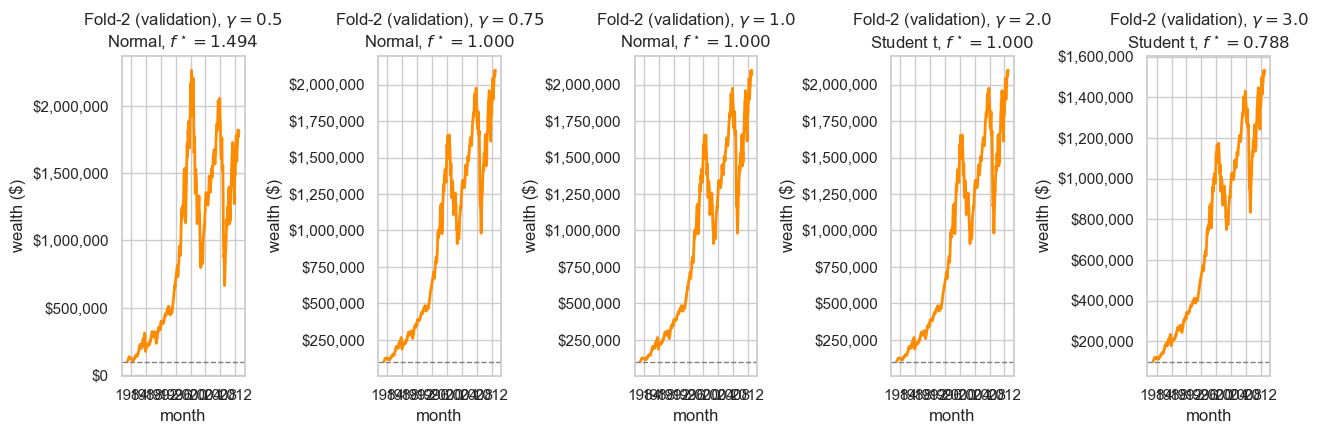

In [10]:
fig, axes = plt.subplots(1, len(test_gammas), figsize=(13, 4.5), sharey=False)
for ax, g in zip(axes, test_gammas):
    dates_v, wealth_v = val_paths[g]
    ax.plot(dates_v, wealth_v, lw=2, color="darkorange")
    ax.axhline(100_000.0, color="0.5", ls="--", lw=1)
    ax.set(title=f"Fold-2 (validation), $\\gamma = {g}$\n{winning_models[g]}, $f^\\star = {f_winners[g]:.3f}$",
           xlabel="month", ylabel="wealth ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Test stage: wealth paths on the combined post-2012 fold

Same wealth-evolution equation, now on the test fold (2013-01 onward, $n = 159$ months) that played no role in fitting or selection. The test period includes the March 2020 COVID drawdown, the 2022 bear market, and the 2018 Q4 selloff — i.e., it is not a uniformly benign sample. We then compare against the fold-2 paths to read off the winner's curse.

In [11]:
test_paths = {g: wealth_path(folds["test (folds 3+4)"], f_winners[g]) for g in test_gammas}

comparison = pd.DataFrame({
    (f"gamma={g}, {winning_models[g]}, f*={f_winners[g]:.3f}", stage):
        path_summary(path[1])
    for g in test_gammas
    for stage, path in [("fold 2 (validation)", val_paths[g]), ("test (folds 3+4)", test_paths[g])]
})
comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
comparison

gamma=0.5, Normal, f*=1.494                   \
                                fold 2 (validation) test (folds 3+4)   
starting wealth                            $100,000         $100,000   
terminal wealth                          $1,814,936         $785,114   
annualized growth ratio                      1.1014           1.1683   
max drawdown                                 -70.6%           -37.2%   
n_months                                        360              159   

                        gamma=0.75, Normal, f*=1.000                   \
                                 fold 2 (validation) test (folds 3+4)   
starting wealth                             $100,000         $100,000   
terminal wealth                           $2,099,209         $570,550   
annualized growth ratio                       1.1068           1.1405   
max drawdown                                  -50.3%           -24.8%   
n_months                                         360              159   

                        gamma=1.0, Normal, f*=1.000                   \
                                fold 2 (validation) test (folds 3+4)   
starting wealth                            $100,000         $100,000   
terminal wealth                          $2,099,209         $570,550   
annualized growth ratio                      1.1068           1.1405   
max drawdown                                 -50.3%           -24.8%   
n_months                                        360              159   

                        gamma=2.0, Student t, f*=1.000                   \
                                   fold 2 (validation) test (folds 3+4)   
starting wealth                               $100,000         $100,000   
terminal wealth                             $2,099,209         $570,550   
annualized growth ratio                         1.1068           1.1405   
max drawdown                                    -50.3%           -24.8%   
n_months                                           360              159   

                        gamma=3.0, Student t, f*=0.788                   
                                   fold 2 (validation) test (folds 3+4)  
starting wealth                               $100,000         $100,000  
terminal wealth                             $1,533,891         $423,457  
annualized growth ratio                         1.0953           1.1151  
max drawdown                                    -41.7%           -19.8%  
n_months                                           360              159

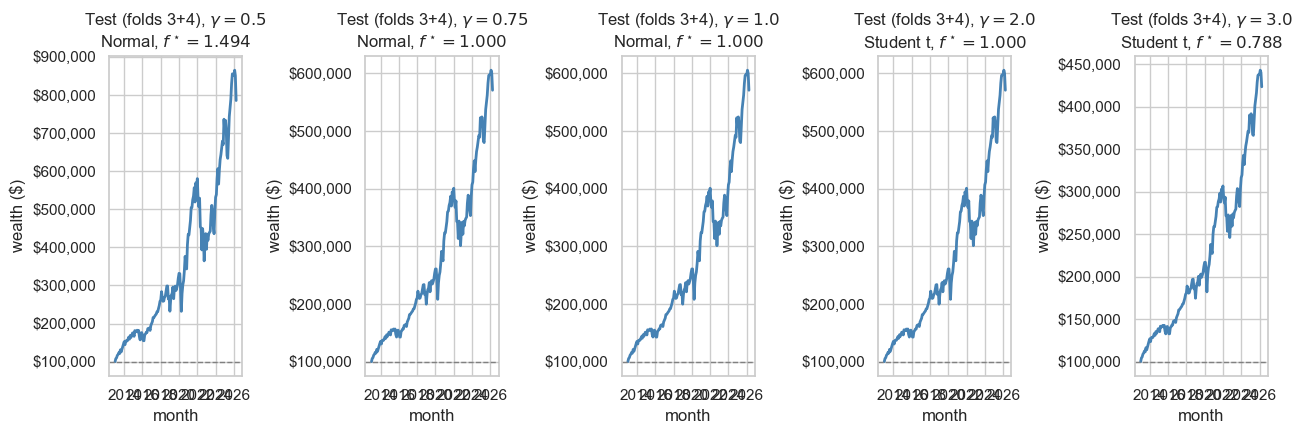

In [12]:
fig, axes = plt.subplots(1, len(test_gammas), figsize=(13, 4.5), sharey=False)
for ax, g in zip(axes, test_gammas):
    dates_t, wealth_t = test_paths[g]
    ax.plot(dates_t, wealth_t, lw=2, color="steelblue")
    ax.axhline(100_000.0, color="0.5", ls="--", lw=1)
    ax.set(title=f"Test (folds 3+4), $\\gamma = {g}$\n{winning_models[g]}, $f^\\star = {f_winners[g]:.3f}$",
           xlabel="month", ylabel="wealth ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Distribution of realized monthly log-growth on the test fold

The CRRA objective at $\gamma = 1$ is mean log-growth, and log-growth is the natural growth diagnostic at every $\gamma$. For each winning portfolio we histogram the realized monthly $\log(\text{gross}_t)$ over the test fold (folds 3+4), with the mean (dashed) — the realized out-of-sample growth rate the strategy actually delivered. Higher mean and a less catastrophic left tail is better. This is the analogue of the log-growth histograms in `4_copula_nco.ipynb`.

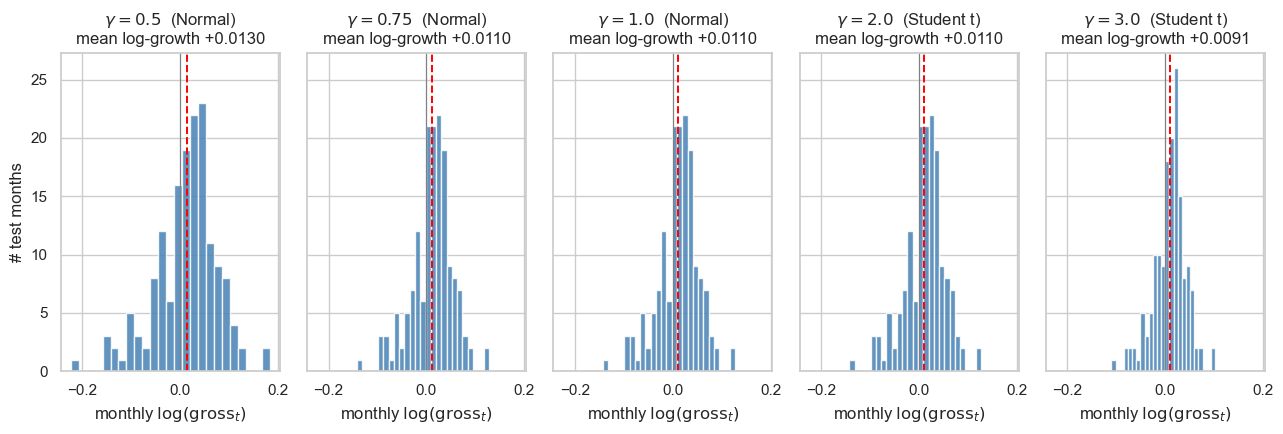

In [13]:
fig, axes = plt.subplots(1, len(test_gammas), figsize=(13, 4.5), sharex=True, sharey=True)
for ax, g in zip(axes, test_gammas):
    fold_df = folds["test (folds 3+4)"]
    gross = gross_return(f_winners[g], fold_df["r_mkt"].values,
                         fold_df["r_f"].values, S_MONTHLY)
    lg = np.log(np.maximum(gross, EPS))
    ax.hist(lg, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(lg.mean(), color="red", ls="--", lw=1.4)
    ax.axvline(0.0, color="0.5", lw=0.8)
    ax.set(title=f"$\\gamma = {g}$  ({winning_models[g]})\n"
               f"mean log-growth {lg.mean():+.4f}",
           xlabel=r"monthly $\log(\mathrm{gross}_t)$")
axes[0].set_ylabel("# test months")
plt.tight_layout()
plt.show()

## Caveats for class discussion

**Winner's curse.** The fold-2 statistics belong to the strategies that *won* the validation race at each $\gamma$. By construction, those strategies were selected because they did best on fold 2 — so their fold-2 performance is an *upward-biased* estimate of how they will do on data they have never seen. Chapter 11.8's expectation: the test fold should look *worse* than the validation fold. In this dataset the picture is mixed: the post-2012 test sample has a strong bull-market drift that boosts annualized growth, but at the same time the test fold is small ($n = 159$) and includes only one and a half bear markets (2020, 2022) while fold 2 includes three (1987, 2000–2002, 2008). A test fold that included a 1929- or 2008-class event would likely show the canonical pattern more cleanly.

**No refinement after the test.** If we now look at the test wealth paths, think "I bet a different $\gamma$ or a different model would have looked even better," and re-run, we have spent the test set. There is no further held-out fold to fall back on.

**Truncation at $m = -0.6$.** We capped simulated draws below at $-0.6$ — twice the worst monthly market return ever observed ($\approx -0.30$). This is a modeling choice: it prevents Student-$t$'s fitted $df \approx 3.45$ tail from producing $m < -1$ draws that the optimizer would otherwise take seriously. Realized validation- and test-fold returns are used as-is; the cap applies only to the model-generated draws used during optimization. Without this cap Student-$t$ would recommend more conservative $f^\star$, but the conservativeness would be paying for tail outcomes that cannot physically occur.

**Borrowing spread.** We use $s = 5\%$ annual throughout, which is in the retail-margin range. Two extensions for class discussion: (i) the spread could be made time-varying to reflect the fact that margin rates also move with the policy rate; (ii) the "no spread" textbook baseline ($s = 0$) would recommend substantially higher $f^\star$ when the unconstrained leverage exceeds 1, and would be unchanged at high $\gamma$ where $f^\star \le 1$. The size of the gap between $s = 0$ and $s = 5\%$ is largest where the unconstrained $f^\star$ is well above 1.